# CT Data Joining
------------------------
**Dr. Dave Wanik - University of Connecticut**

Here is a way to join a .csv file to a geopandas dataframe - bring your CSV data to life!!!

In [ ]:
!pip install adjustText

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# CT Towns shapefile (and surrounding towns)

In [ ]:
# Northeastern USA Town data (useful for your final project!)
# https://drive.google.com/file/d/1cEZBYENFaJ59R1nm0M0E9Q2rqZI6_Yc2/view?usp=sharing
!gdown 1cEZBYENFaJ59R1nm0M0E9Q2rqZI6_Yc2

Downloading...
From: https://drive.google.com/uc?id=1cEZBYENFaJ59R1nm0M0E9Q2rqZI6_Yc2
To: /content/Connecticut_and_Vicinity_Town_Boundary_Set_2617795301392764759.zip
100% 3.30M/3.30M [00:00<00:00, 139MB/s]


In [ ]:
!unzip Connecticut_and_Vicinity_Town_Boundary_Set_2617795301392764759.zip

Archive:  Connecticut_and_Vicinity_Town_Boundary_Set_2617795301392764759.zip
  inflating: CT_Vicinity_Town_Polygon.cpg  
  inflating: CT_Vicinity_Town_Polygon.dbf  
  inflating: CT_Vicinity_Town_Polygon.prj  
  inflating: CT_Vicinity_Town_Polygon.shp  
  inflating: CT_Vicinity_Town_Polygon.shx  


In [ ]:
# read the data
url = 'CT_Vicinity_Town_Polygon.shp'
towns = gpd.read_file(url)

# check out the head
towns.head()

,LAND_CLASS,CT_LEGEND,STATE_COD,STATE_NAME,CNTY_FIELD,CNTY_COD,CNTY_NAME,TOWN_FIELD,TOWN_NAME,LABEL_FLAG,MAP_LABEL,CT_LABEL_Y,CT_LABEL_N,geometry
0,Land,Other States,MA,Massachusetts,FIPS-COUNTY,27.0,Worcester,TOWN-ID,Uxbridge,True,Uxbridge,None,Uxbridge,"POLYGON ((1314474.251 950430.875, 1314007.251 ..."
1,Land,Other States,MA,Massachusetts,FIPS-COUNTY,21.0,Norfolk,TOWN-ID,Foxborough,True,Foxborough,None,Foxborough,"POLYGON ((1426805.375 949926.625, 1421795.625 ..."
2,Land,Other States,MA,Massachusetts,FIPS-COUNTY,27.0,Worcester,TOWN-ID,Southbridge,True,Southbridge,None,Southbridge,"POLYGON ((1205552.751 952445.875, 1205636.501 ..."
3,Land,Other States,MA,Massachusetts,FIPS-COUNTY,5.0,Bristol,TOWN-ID,Easton,True,Easton,None,Easton,"POLYGON ((1437395.589 928737.738, 1437395.589 ..."
4,Land,Other States,MA,Massachusetts,FIPS-COUNTY,13.0,Hamden,TOWN-ID,Agawam,True,Agawam,None,Agawam,"POLYGON ((1043830.001 959124.501, 1043763.375 ..."


In [ ]:
towns.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   LAND_CLASS  1780 non-null   object  
 1   CT_LEGEND   1780 non-null   object  
 2   STATE_COD   1779 non-null   object  
 3   STATE_NAME  1779 non-null   object  
 4   CNTY_FIELD  1774 non-null   object  
 5   CNTY_COD    1780 non-null   float64 
 6   CNTY_NAME   1770 non-null   object  
 7   TOWN_FIELD  1774 non-null   object  
 8   TOWN_NAME   1770 non-null   object  
 9   LABEL_FLAG  1780 non-null   object  
 10  MAP_LABEL   655 non-null    object  
 11  CT_LABEL_Y  169 non-null    object  
 12  CT_LABEL_N  486 non-null    object  
 13  geometry    1780 non-null   geometry
dtypes: float64(1), geometry(1), object(12)
memory usage: 194.8+ KB


## New England towns colored by State

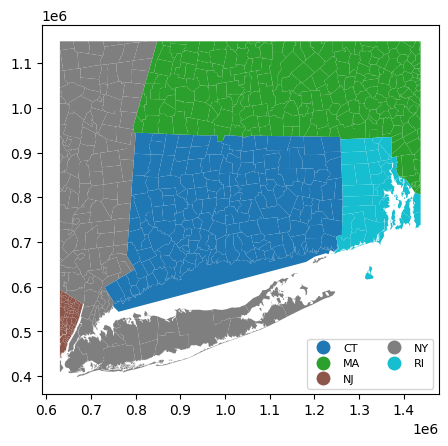

In [ ]:
# make a plot! yes, it's that easy!
towns.plot(column='STATE_COD',
           legend=True,
           legend_kwds={'loc': 'lower right',
                      'fontsize': 8,
                      'ncols':2}) # you can add legend keywords
plt.show()

## Subset just CT towns

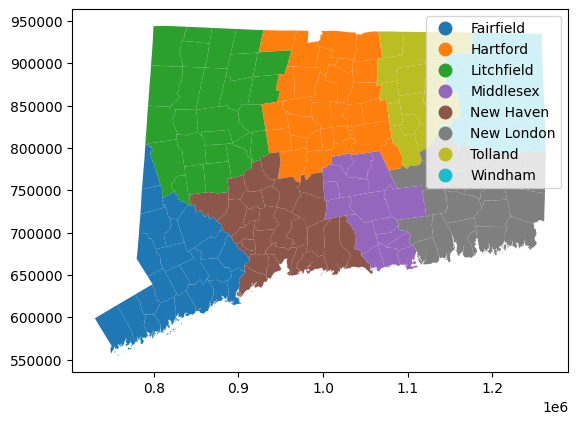

In [ ]:
towns = towns[towns['STATE_COD']=='CT'] # CT towns
towns = towns[towns['LAND_CLASS']=='Land']# land only
towns.plot(column='CNTY_NAME', legend=True) # add some legend keywords to clean it up!
plt.show()

In [ ]:
towns.shape

(783, 14)

In [ ]:
towns.crs

<Projected CRS: EPSG:2234>
Name: NAD83 / Connecticut (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Connecticut - counties of Fairfield; Hartford; Litchfield; Middlesex; New Haven; New London; Tolland; Windham.
- bounds: (-73.73, 40.98, -71.78, 42.05)
Coordinate Operation:
- name: SPCS83 Connecticut zone (US Survey feet)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

# Join a .csv file to the shapefile
You need to be careful that your data stays a gdf (geodataframe!)

## Read a .csv file...

In [23]:
# https://drive.google.com/file/d/1Ygw7VV01nm11H_1imbnMoRaXEGhe_6NK/view?usp=sharing
!gdown 1Ygw7VV01nm11H_1imbnMoRaXEGhe_6NK

Downloading...
From: https://drive.google.com/uc?id=1Ygw7VV01nm11H_1imbnMoRaXEGhe_6NK
To: /content/children_by_family_type-2020.csv
100% 19.1M/19.1M [00:00<00:00, 57.9MB/s]


In [24]:
df = pd.read_csv('/content/children_by_family_type-2020.csv')

In [ ]:
# https://github.com/orgs/CT-Data-Collaborative/repositories
# ^ you can grab your own table to explore!
# df = pd.read_csv('https://raw.githubusercontent.com/CT-Data-Collaborative/children-by-family-type/master/data/children_by_family_type-2020.csv')

In [ ]:
df.head(n=20)

,Town,Year,Family Type,Age of Child,Measure Type,Variable,Value
0,Andover,2006-2010,Married-couple Family,Total,Number,Children Under 18,576.00
1,Andover,2006-2010,Married-couple Family,Total,Number,Margins of Error,119.00
2,Andover,2006-2010,Married-couple Family,Total,Percent,Children Under 18,87.01
3,Andover,2006-2010,Married-couple Family,Total,Percent,Margins of Error,23.83
4,Andover,2006-2010,Married-couple Family,Under 3 years,Number,Children Under 18,98.00
5,Andover,2006-2010,Married-couple Family,Under 3 years,Number,Margins of Error,50.00
6,Andover,2006-2010,Married-couple Family,Under 3 years,Percent,Children Under 18,14.80
7,Andover,2006-2010,Married-couple Family,Under 3 years,Percent,Margins of Error,8.01
8,Andover,2006-2010,Married-couple Family,3 to 4 years,Number,Children Under 18,80.00
9,Andover,2006-2010,Married-couple Family,3 to 4 years,Number,Margins of Error,34.00


In [ ]:
df['Year'].value_counts()

2006-2010    20060
2007-2011    20060
2008-2012    20060
2009-2013    20060
2010-2014    20060
2011-2015    20060
2012-2016    20060
2013-2017    20060
2014-2018    20060
2015-2019    20060
2016-2020    20060
Name: Year, dtype: int64

In [ ]:
df.to_csv('children_by_family_type-2020.csv',
          index=False)

## Join to the geodataframe

In [ ]:
# prompt: join towns on TOWN_NAME and df on Town

towns_with_children = gpd.GeoDataFrame(pd.merge(left=towns, # this is the gdf
                                                right=df, # this is the csv file
                                                left_on='TOWN_NAME',
                                                right_on='Town'),
                                       geometry='geometry') # this is the name of the geometry field
# this info helps you check your work
towns_with_children.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 1016334 entries, 0 to 1016333
Data columns (total 21 columns):
 #   Column        Non-Null Count    Dtype   
---  ------        --------------    -----   
 0   LAND_CLASS    1016334 non-null  object  
 1   CT_LEGEND     1016334 non-null  object  
 2   STATE_COD     1016334 non-null  object  
 3   STATE_NAME    1016334 non-null  object  
 4   CNTY_FIELD    1016334 non-null  object  
 5   CNTY_COD      1016334 non-null  float64 
 6   CNTY_NAME     1016334 non-null  object  
 7   TOWN_FIELD    1016334 non-null  object  
 8   TOWN_NAME     1016334 non-null  object  
 9   LABEL_FLAG    1016334 non-null  object  
 10  MAP_LABEL     219362 non-null   object  
 11  CT_LABEL_Y    219362 non-null   object  
 12  CT_LABEL_N    0 non-null        object  
 13  geometry      1016334 non-null  geometry
 14  Town          1016334 non-null  object  
 15  Year          1016334 non-null  object  
 16  Family Type   1016334 non-null  object  
 17  

In [ ]:
towns_with_children.head()

,LAND_CLASS,CT_LEGEND,STATE_COD,STATE_NAME,CNTY_FIELD,CNTY_COD,CNTY_NAME,TOWN_FIELD,TOWN_NAME,LABEL_FLAG,...,CT_LABEL_Y,CT_LABEL_N,geometry,Town,Year,Family Type,Age of Child,Measure Type,Variable,Value
0,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,...,Salisbury,None,"POLYGON ((839572.437 943276.875, 838568.251 94...",Salisbury,2006-2010,Married-couple Family,Total,Number,Children Under 18,299.0
1298,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,North Canaan,True,...,North Canaan,None,"POLYGON ((851614.937 942698.187, 849750.437 94...",North Canaan,2006-2010,Married-couple Family,Total,Number,Children Under 18,273.0
2596,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Norfolk,True,...,Norfolk,None,"POLYGON ((885330.625 941199.187, 881530.687 94...",Norfolk,2006-2010,Married-couple Family,Total,Number,Children Under 18,279.0
3894,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Colebrook,True,...,Colebrook,None,"POLYGON ((917666.875 939747.251, 916177.375 93...",Colebrook,2006-2010,Married-couple Family,Total,Number,Children Under 18,215.0
5192,Land,Connecticut,CT,Connecticut,CNTY_COD,2.0,Hartford,TOWN_NO,Hartland,True,...,Hartland,None,"POLYGON ((937783.125 939127.187, 937564.251 93...",Hartland,2006-2010,Married-couple Family,Total,Number,Children Under 18,447.0


Now you can subset and explore your data!

In [ ]:
# condition 1
towns_with_children = towns_with_children[towns_with_children['Year']=='2006-2010']
# condition 2
towns_with_children = towns_with_children[towns_with_children['Family Type']=='Married-couple Family']
# condition 3
towns_with_children = towns_with_children[towns_with_children['Age of Child']=='Total']
# condition 4
towns_with_children = towns_with_children[towns_with_children['Measure Type']=='Number']
# condition 5
towns_with_children = towns_with_children[towns_with_children['Variable']=='Children Under 18']
# check the shape!
towns_with_children.shape # 22!

(783, 21)

783?! That is a lot bigger than the 169 towns in Connecticut... what is going on?!

In [ ]:
# branford has a lot of islands! don't worry about it
towns_with_children['Town'].value_counts()

Branford      154
Greenwich      66
Westport       64
Milford        48
East Lyme      35
             ... 
Plainfield      1
Andover         1
Canterbury      1
Windham         1
Sprague         1
Name: Town, Length: 169, dtype: int64

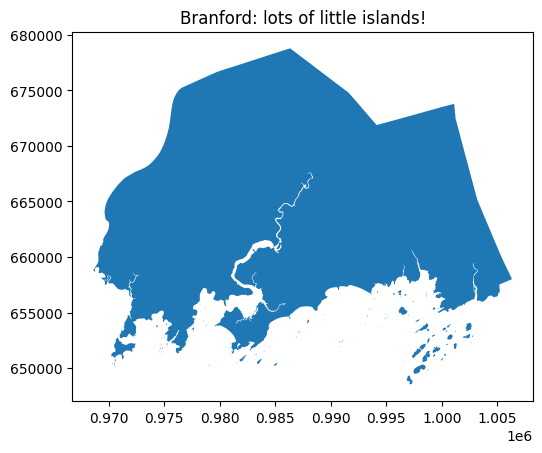

In [ ]:
tmp = towns_with_children[towns_with_children['Town']=='Branford']
tmp.plot()
plt.title('Branford: lots of little islands!')
plt.show()

In [ ]:
towns_with_children.head()

,LAND_CLASS,CT_LEGEND,STATE_COD,STATE_NAME,CNTY_FIELD,CNTY_COD,CNTY_NAME,TOWN_FIELD,TOWN_NAME,LABEL_FLAG,...,CT_LABEL_Y,CT_LABEL_N,geometry,Town,Year,Family Type,Age of Child,Measure Type,Variable,Value
0,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,...,Salisbury,None,"POLYGON ((839572.437 943276.875, 838568.251 94...",Salisbury,2006-2010,Married-couple Family,Total,Number,Children Under 18,299.0
1298,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,North Canaan,True,...,North Canaan,None,"POLYGON ((851614.937 942698.187, 849750.437 94...",North Canaan,2006-2010,Married-couple Family,Total,Number,Children Under 18,273.0
2596,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Norfolk,True,...,Norfolk,None,"POLYGON ((885330.625 941199.187, 881530.687 94...",Norfolk,2006-2010,Married-couple Family,Total,Number,Children Under 18,279.0
3894,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Colebrook,True,...,Colebrook,None,"POLYGON ((917666.875 939747.251, 916177.375 93...",Colebrook,2006-2010,Married-couple Family,Total,Number,Children Under 18,215.0
5192,Land,Connecticut,CT,Connecticut,CNTY_COD,2.0,Hartford,TOWN_NO,Hartland,True,...,Hartland,None,"POLYGON ((937783.125 939127.187, 937564.251 93...",Hartland,2006-2010,Married-couple Family,Total,Number,Children Under 18,447.0


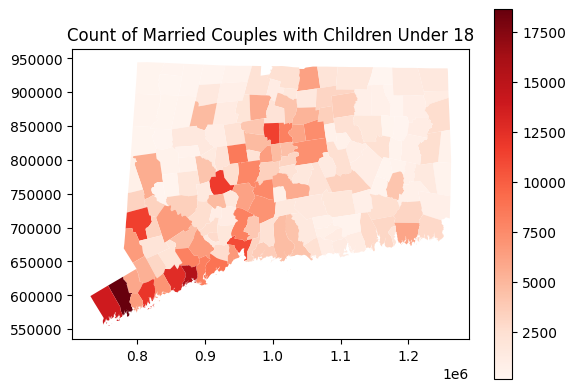

In [ ]:
# a simple plot
towns_with_children.plot(column='Value', legend=True, cmap='Reds')
plt.title('Count of Married Couples with Children Under 18')
plt.show()

# 🦾 Explore your own dataset!
* Pay attention to percent vs. number for the measure type.
* Where is the uncertainty (margin of error) the biggest?
* Can you make a low and high estimate for each variable?